# Titanic: From zero to submission
Objective: predict Survived using passenger features. This notebook runs EDA → preprocessing → modeling → submission.


In [34]:
# Cell: imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Optional (install if on local environment)
import xgboost as xgb
import lightgbm as lgb

# For SHAP (interpretation) - optional
import shap

sns.set_style('whitegrid')


In [13]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
gender_sub = pd.read_csv('gender_submission.csv')  # example baseline
train.shape, test.shape


((891, 12), (418, 11))

In [14]:
# Quick baseline: female -> survived, male -> died (this is the provided gender_submission example)
baseline = gender_sub.copy()
baseline.head()
# (Submit baseline to Kaggle to get an initial benchmark)


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [15]:
display(train.head())
print(train.info())
print(train.isnull().sum())
# Survival rates by Sex and Pclass
display(pd.crosstab(train['Sex'], train['Survived'], normalize='index'))
display(pd.crosstab(train['Pclass'], train['Survived'], normalize='index'))


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int6

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


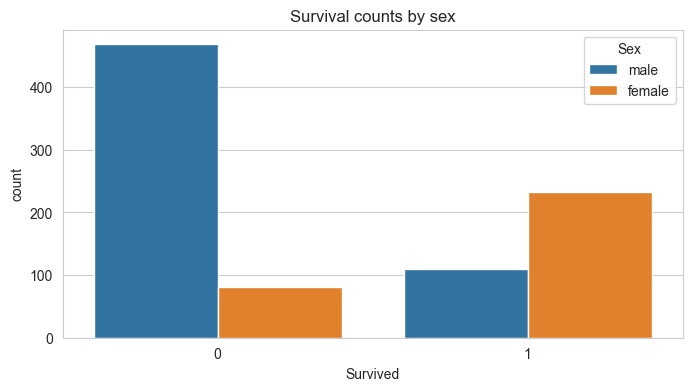

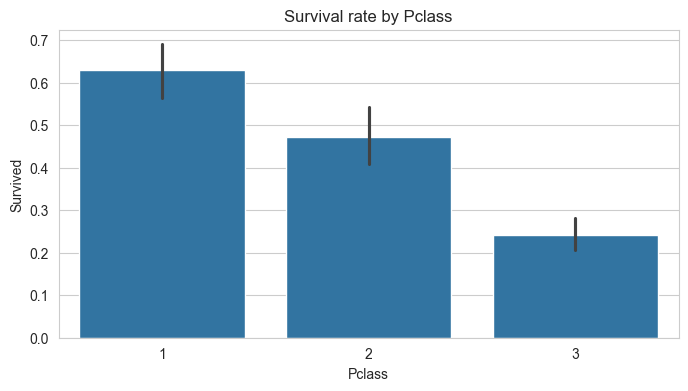

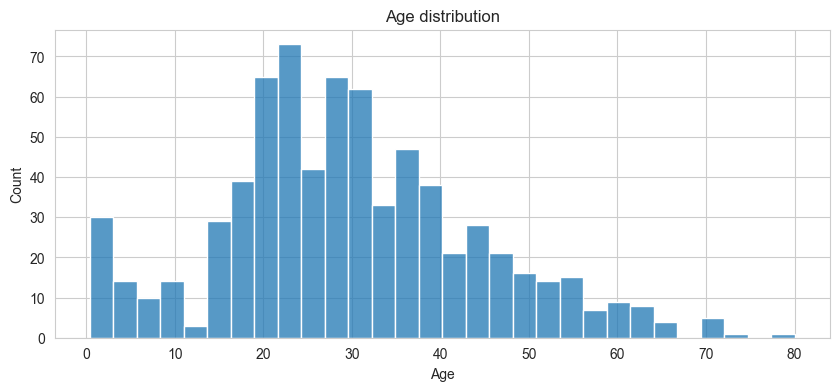

In [16]:
plt.figure(figsize=(8,4))
sns.countplot(x='Survived', hue='Sex', data=train)
plt.title('Survival counts by sex')
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(x='Pclass', y='Survived', data=train)
plt.title('Survival rate by Pclass')
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(train['Age'].dropna(), bins=30, kde=False)
plt.title('Age distribution')
plt.show()


In [17]:
def extract_title(name):
    # common titles mapping
    title = name.split(',')[1].split('.')[0].strip()
    return title

def create_features(df):
    df = df.copy()
    # Title
    df['Title'] = df['Name'].apply(extract_title)
    rare_titles = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
    df['Title'] = df['Title'].replace(['Mlle','Ms'],'Miss')
    df['Title'] = df['Title'].replace('Mme','Mrs')
    df['Title'] = df['Title'].apply(lambda t: 'Rare' if t in rare_titles else t)
    
    # Family size
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # Cabin deck (first letter). Many missing-> keep as 'Unknown'
    df['CabinDeck'] = df['Cabin'].fillna('Unknown').apply(lambda x: x[0] if x != 'Unknown' else 'U')
    
    # Ticket prefix
    df['TicketPrefix'] = df['Ticket'].apply(lambda x: x.replace('.', '').replace('/', '').split()[0] if not x.isdigit() else 'NUM')
    df['TicketPrefix'] = df['TicketPrefix'].apply(lambda t: t if any(c.isalpha() for c in t) else 'NUM')
    
    # FarePerPerson
    df['FarePerPerson'] = df['Fare'] / df['FamilySize']
    
    return df


In [18]:
train_fe = create_features(train)
test_fe  = create_features(test)
train_fe.shape, test_fe.shape


((891, 18), (418, 17))

In [19]:
# Select features
features = ['Pclass','Sex','Age','Fare','Embarked','Title','FamilySize','IsAlone','CabinDeck','TicketPrefix','FarePerPerson']
X = train_fe[features]
y = train_fe['Survived']
X_test = test_fe[features]

# Preprocessing: numeric and categorical
numeric_features = ['Age','Fare','FamilySize','FarePerPerson']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Pclass','Sex','Embarked','Title','IsAlone','CabinDeck','TicketPrefix']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


In [20]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
print('Logistic Regression CV accuracy: %.4f ± %.4f' % (scores.mean(), scores.std()))


Logistic Regression CV accuracy: 0.8215 ± 0.0155


In [21]:
if lgb is not None:
    lgb_clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', lgb.LGBMClassifier(random_state=42, n_estimators=500))
    ])
    print('LightGBM CV:', cross_val_score(lgb_clf, X, y, cv=cv, scoring='accuracy').mean())

if xgb is not None:
    xgb_clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
    ])
    print('XGBoost CV:', cross_val_score(xgb_clf, X, y, cv=cv, scoring='accuracy').mean())


[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000565 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 357
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

c:\Users\pc\.conda\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 274, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000150 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 355
[LightGBM] [Info] Number of data points in the train set: 713, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.384292 -> initscore=-0.471371
[LightGBM] [Info] Start training from score -0.471371
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

c:\Users\pc\.conda\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 274, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000168 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 363
[LightGBM] [Info] Number of data points in the train set: 713, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.384292 -> initscore=-0.471371
[LightGBM] [Info] Start training from score -0.471371
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

c:\Users\pc\.conda\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 274, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000263 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 359
[LightGBM] [Info] Number of data points in the train set: 713, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.384292 -> initscore=-0.471371
[LightGBM] [Info] Start training from score -0.471371
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

c:\Users\pc\.conda\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

c:\Users\pc\.conda\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\pc\.conda\envs\tf_env\lib\site-packages\xgboost\training.py:199: UserWarning: [09:26:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\pc\.conda\envs\tf_env\lib\site-packages\xgboost\training.py:199: UserWarning: [09:26:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\pc\.conda\envs\tf_env\lib\site-packages\xgboost\training.py:199: UserWarning: [09:26:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\pc\

XGBoost CV: 0.8259807921662168


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Assume X, y, and cv are defined previously

# Initialize the Random Forest pipeline with preprocessor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Parameter distribution with 'classifier__' prefixes for Pipeline
param_dist = {
    'classifier__n_estimators': [100, 200, 500],
    'classifier__max_depth': [None, 4, 6, 8],
    'classifier__min_samples_split': [2, 4, 6],
    'classifier__min_samples_leaf': [1, 2, 3]
}

# Use the pipeline in RandomizedSearchCV
search = RandomizedSearchCV(rf_pipeline, param_distributions=param_dist, n_iter=12, cv=cv, scoring='accuracy', random_state=42, n_jobs=-1)

# This will now work
search.fit(X, y)
print('Best CV score:', search.best_score_)
print('Best params:', search.best_params_)

# Extract the best estimator for later use
best_rf = search.best_estimator_


Best CV score: 0.8361182599962337
Best params: {'classifier__n_estimators': 500, 'classifier__min_samples_split': 4, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 8}


In [29]:
estimators = []
# logistic
estimators.append(('lr', clf))
# tuned rf
estimators.append(('rf', best_rf))
# optionally add xgb/lgb if present
if xgb is not None:
    estimators.append(('xgb', xgb_clf))
if lgb is not None:
    estimators.append(('lgb', lgb_clf))

voting = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
scores_v = cross_val_score(voting, X, y, cv=cv, scoring='accuracy')
print('Voting CV accuracy: %.4f ± %.4f' % (scores_v.mean(), scores_v.std()))
# Fit on full training data before making predictions
voting.fit(X, y)


c:\Users\pc\.conda\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\pc\.conda\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\pc\.conda\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\pc\.conda\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\pc\.conda\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Voting CV accuracy: 0.8350 ± 0.0138


,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,-1
,flatten_transform,True
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None


In [30]:
# If using RandomForest or LightGBM
if hasattr(best_rf.named_steps['classifier'], 'feature_importances_'):
    # need feature names from preprocessor
    ohe = best_rf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe']
    cat_cols = ohe.get_feature_names_out(categorical_features)
    all_cols = numeric_features + list(cat_cols)
    importances = best_rf.named_steps['classifier'].feature_importances_
    fi = pd.Series(importances, index=all_cols).sort_values(ascending=False)
    display(fi.head(20))


Title_Mr            0.147750
Sex_female          0.134077
Sex_male            0.114484
FarePerPerson       0.086804
Fare                0.076029
Age                 0.059205
Pclass_3            0.049957
Title_Mrs           0.049795
Title_Miss          0.047764
FamilySize          0.041914
CabinDeck_U         0.035350
Pclass_1            0.024527
Pclass_2            0.014206
Title_Master        0.012458
Embarked_S          0.011668
IsAlone_0           0.010222
IsAlone_1           0.009975
Embarked_C          0.009169
CabinDeck_E         0.006927
TicketPrefix_NUM    0.005949
dtype: float64

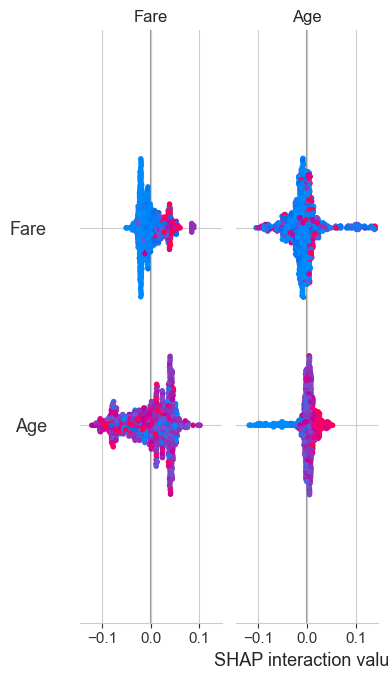

In [32]:
if shap is not None and hasattr(best_rf.named_steps['classifier'], 'feature_importances_'):
    # Create an explainer on the transformed data
    X_trans = best_rf.named_steps['preprocessor'].transform(X).toarray()
    explainer = shap.TreeExplainer(best_rf.named_steps['classifier'])
    shap_values = explainer.shap_values(X_trans)
    shap.summary_plot(shap_values, X_trans, feature_names=all_cols, show=True)
else:
    print("SHAP not available or model not tree-based. You can pip install shap locally.")


In [33]:
# Predict test set
preds = voting.predict(X_test)
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': preds.astype(int)
})
submission.to_csv('submission.csv', index=False)
print('Saved submission.csv; rows =', submission.shape[0])


Saved submission.csv; rows = 418


c:\Users\pc\.conda\envs\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
